# 03. 배터리 수명 예측 모델링 및 성능 평가

본 노트북은 **Batch 1**을 학습/검증 데이터셋으로, **Batch 2**를 최종 테스트 데이터셋으로 활용하여 최적의 머신러닝 모델을 개발하고, **Nature Energy (2019) 원논문 성능(9.1% MAPE)**과 비교 분석합니다.

- **Train (Batch 1 CV)**: Batch 1 내 5-Fold Cross-Validation 평균 성능
- **Valid (Batch 1 Hold-out)**: 동일 프로토콜 분리를 보장한 Hold-out 검증 성능 (데이터 누수 방지)
- **Test (Batch 2)**: Batch 2 최종 평가 성능 및 배치 간 일반화 저하 분석


In [28]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../src')
from preprocess import load_processed_data
from features import extract_features, FEATURE_SETS
from train import run_training_pipeline

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['AppleGothic', 'NanumGothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False



## 1. 모델 학습 및 평가 파이프라인 실행


In [29]:
df_results, b2_errors = run_training_pipeline(output_dir='../results')
display(df_results)


1. Loading data & extracting features...
   • Batch 1 (Train/Valid Pool): 46 cells
   • Batch 2 (Test Set)        : 39 cells
   • Batch 1 Protocol-based Hold-out: Train=37 cells, Valid=9 cells

Evaluating Feature Set: Level 1 (Variance) (1 features)...

Evaluating Feature Set: Level 2 (Discharge) (9 features)...

Evaluating Feature Set: Level 3 (Full) (13 features)...

[Saved] Performance table saved to ../results/model_performance.csv
[Saved] Error analysis saved to ../results/error_analysis.csv

📊 [Reporting Format (for Regression) - Best Representative Models]

▶ 원논문 대표 모델: Full Model (ElasticNet)
-----------------------------------------------------------------
| 구분                        | MAPE (%)   | 비고                     |
|---------------------------|------------|------------------------|
| Train (Batch 1 CV)        |      6.29% |                        |
| Valid (Batch 1 Hold-out)  |      9.07% |                        |
| Test (Batch 2)            |     39.59% |            

,Feature_Set,Model,Train (Batch 1 CV),Valid (Batch 1 Hold-out),Test (Batch 2),Test RMSE (cycles),Gap (Train-Valid),Gap (Valid-Test),Gap (Target-Test)
0,Level 1 (Variance),"ElasticNet (alpha=0.01, l1=0.5)",9.71,17.16,36.69,188.1,7.46,19.52,27.59
1,Level 1 (Variance),Ridge (alpha=1.0),9.63,18.64,35.42,182.6,9.02,16.78,26.32
2,Level 1 (Variance),"RandomForest (depth=3, n=50)",6.93,6.41,28.57,157.9,-0.52,22.16,19.47
3,Level 1 (Variance),"GradientBoosting (depth=3, n=50)",7.64,7.22,31.86,173.9,-0.42,24.64,22.76
4,Level 2 (Discharge),"ElasticNet (alpha=0.01, l1=0.5)",6.11,8.26,39.50,219.2,2.15,31.24,30.40
5,Level 2 (Discharge),Ridge (alpha=1.0),6.01,9.28,43.98,249.5,3.27,34.70,34.88
6,Level 2 (Discharge),"RandomForest (depth=3, n=50)",7.61,6.33,32.64,175.0,-1.27,26.31,23.54
7,Level 2 (Discharge),"GradientBoosting (depth=3, n=50)",7.45,8.37,39.84,203.2,0.92,31.47,30.74
8,Level 3 (Full),"ElasticNet (alpha=0.01, l1=0.5)",6.29,9.07,39.59,216.5,2.78,30.53,30.49
9,Level 3 (Full),Ridge (alpha=1.0),6.42,10.39,43.88,242.1,3.96,33.49,34.78


## 2. Reporting Format (for Regression) 성능 결과표


In [30]:
# 원논문 대표 모델: Level 3 ElasticNet
enet_row = df_results[
    (df_results['Feature_Set'] == 'Level 3 (Full)') & 
    (df_results['Model'].str.contains('ElasticNet'))
].iloc[0]

# 최적 비선형 트리 모델: Level 1 RandomForest
rf_row = df_results[
    (df_results['Feature_Set'] == 'Level 1 (Variance)') & 
    (df_results['Model'].str.contains('RandomForest'))
].iloc[0]

def make_reporting_table(row, title):
    table_data = [
        {'구분': 'Train (Batch 1 CV)', 'MAPE (%)': f"{row['Train (Batch 1 CV)']:.2f}%", '비고': 'Batch 1 5-Fold CV 평균 성능'},
        {'구분': 'Valid (Batch 1 Hold-out)', 'MAPE (%)': f"{row['Valid (Batch 1 Hold-out)']:.2f}%", '비고': '프로토콜 분리 Hold-out 검증'},
        {'구분': 'Test (Batch 2)', 'MAPE (%)': f"{row['Test (Batch 2)']:.2f}%", '비고': 'Batch 2 최종 평가 성능'},
        {'구분': 'Gap (Train-Valid)', 'MAPE (%)': f"{row['Gap (Train-Valid)']:+.2f}%", '비고': '(+) : 과적합 의심'},
        {'구분': 'Gap (Valid-Test)', 'MAPE (%)': f"{row['Gap (Valid-Test)']:+.2f}%", '비고': '(+) : 배치간 일반화 저하 의심'},
        {'구분': 'Gap (Target-Test)', 'MAPE (%)': f"{row['Gap (Target-Test)']:+.2f}%", '비고': 'Target : 원논문 9.1%'}
    ]
    df_rep = pd.DataFrame(table_data)
    print(f'=== {title} ===')
    return df_rep

display(make_reporting_table(enet_row, '원논문 정규화 선형 모델: Level 3 Full (ElasticNet)'))
display(make_reporting_table(rf_row, '최적 머신러닝 모델: Level 1 Variance (RandomForest)'))



=== 원논문 정규화 선형 모델: Level 3 Full (ElasticNet) ===


,구분,MAPE (%),비고
0,Train (Batch 1 CV),6.29%,Batch 1 5-Fold CV 평균 성능
1,Valid (Batch 1 Hold-out),9.07%,프로토콜 분리 Hold-out 검증
2,Test (Batch 2),39.59%,Batch 2 최종 평가 성능
3,Gap (Train-Valid),+2.78%,(+) : 과적합 의심
4,Gap (Valid-Test),+30.53%,(+) : 배치간 일반화 저하 의심
5,Gap (Target-Test),+30.49%,Target : 원논문 9.1%


=== 최적 머신러닝 모델: Level 1 Variance (RandomForest) ===


,구분,MAPE (%),비고
0,Train (Batch 1 CV),6.93%,Batch 1 5-Fold CV 평균 성능
1,Valid (Batch 1 Hold-out),6.41%,프로토콜 분리 Hold-out 검증
2,Test (Batch 2),28.57%,Batch 2 최종 평가 성능
3,Gap (Train-Valid),-0.52%,(+) : 과적합 의심
4,Gap (Valid-Test),+22.16%,(+) : 배치간 일반화 저하 의심
5,Gap (Target-Test),+19.47%,Target : 원논문 9.1%


## 3. 예측 성능 시각화 (Actual vs Predicted & Residuals)


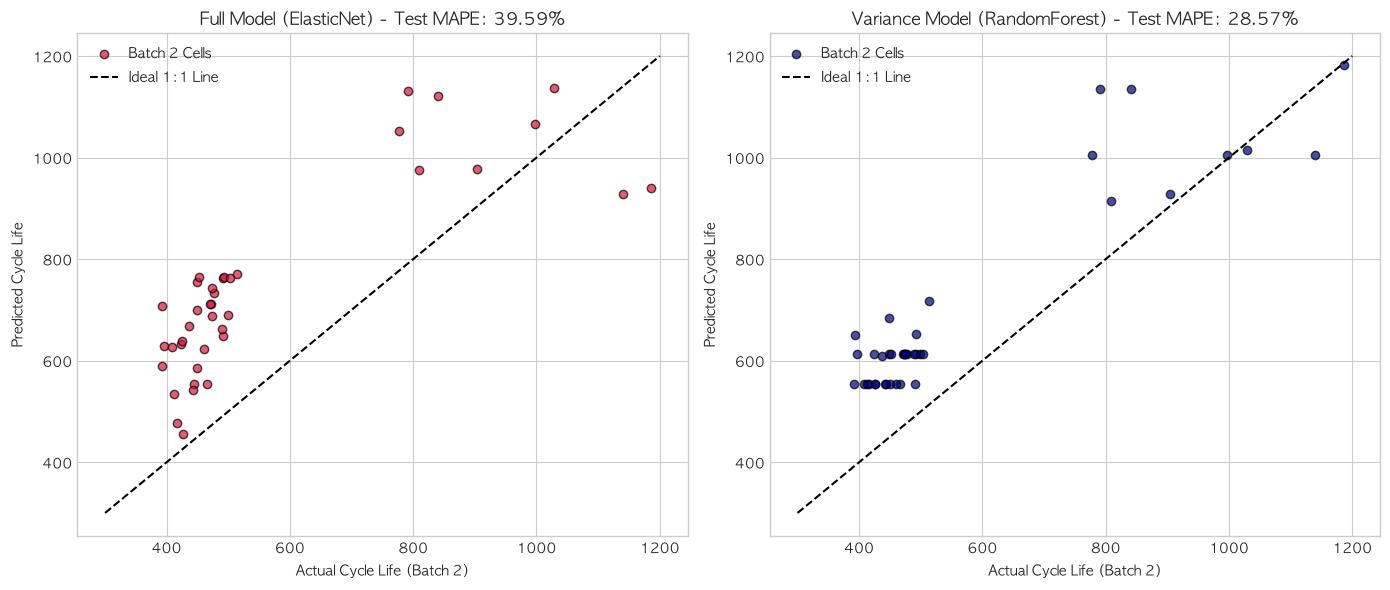

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ElasticNet
axes[0].scatter(b2_errors['cycle_life'], b2_errors['Pred_ElasticNet_Full'], color='crimson', alpha=0.7, edgecolors='k', label='Batch 2 Cells')
axes[0].plot([300, 1200], [300, 1200], 'k--', label='Ideal 1:1 Line')
axes[0].set_xlabel('Actual Cycle Life (Batch 2)')
axes[0].set_ylabel('Predicted Cycle Life')
axes[0].set_title(f"Full Model (ElasticNet) - Test MAPE: {enet_row['Test (Batch 2)']:.2f}%")
axes[0].legend()

# RandomForest
axes[1].scatter(b2_errors['cycle_life'], b2_errors['Pred_RandomForest'], color='navy', alpha=0.7, edgecolors='k', label='Batch 2 Cells')
axes[1].plot([300, 1200], [300, 1200], 'k--', label='Ideal 1:1 Line')
axes[1].set_xlabel('Actual Cycle Life (Batch 2)')
axes[1].set_ylabel('Predicted Cycle Life')
axes[1].set_title(f"Variance Model (RandomForest) - Test MAPE: {rf_row['Test (Batch 2)']:.2f}%")
axes[1].legend()

plt.tight_layout()
plt.show()



## 4. 오류 분석 (Error Analysis) - 오차가 가장 큰 셀들의 특성


In [ ]:
print(' 예측 오차가 가장 큰 상위 5개 셀:')
display(b2_errors.head(5))


🚨 예측 오차가 가장 큰 상위 5개 셀:


,cell_key,policy_readable,cycle_life,Pred_ElasticNet_Full,APE_ElasticNet (%),Pred_RandomForest,APE_RandomForest (%)
0,b2_c0,5.2C(58%)-4C,477.0,734.017716,53.882121,613.073517,28.526943
1,b2_c1,5.6C(26%)-4.5C,491.0,648.107647,31.997484,554.908503,13.015988
2,b2_c2,5.2C(50%)-4.25C,424.0,632.336766,49.136030,612.895694,44.550871
3,b2_c3,4.65C(44%)-5C,499.0,689.855058,38.247507,613.073517,22.860424
4,b2_c4,4.65C(69%)-6C,444.0,553.596753,24.683953,554.908503,24.979393
